# Power-law parameter recovery simulation

既知のパラメータから模擬観測を生成し、`re_sim.model` がべき指数 `a` と太陽年齢での速度 `b` を回収できるか確認する。生成・推定の両方で

$$v(t)=b\left(\frac{t}{4.6\,\mathrm{Gyr}}\right)^a$$

を使用する。各星の真の年齢と傾斜角は潜在変数として推定する。

In [1]:
from pathlib import Path

import arviz as az
import corner
import jax
import matplotlib.pyplot as plt
import numpy as np
from numpyro.infer import MCMC, NUTS
from scipy.stats import truncnorm

from rot_evol import *
from sim_stars_given_age import simulate_stars_given_age, stack_isochrone_samples

jax.config.update("jax_enable_x64", True)

## Generate synthetic observations

年齢は対数的に広く配置し、自転軸は等方的（$\cos i\sim\mathrm{Uniform}(0,1)$）とする。$v\sin i$ にガウス誤差を加える。
`simulate_stars_given_age` で測光・分光量を模擬して星ごとの isochrone posterior を推定し、その年齢分布を `IsochronePosterior` に入力する。

In [2]:
RNG_SEED = 1
N_STARS = 50
ISO_NUM_CHAINS = 4
ISO_NUM_WARMUP = 1000
ISO_NUM_SAMPLES_PER_CHAIN = 1000
N_ISO_SAMPLES = ISO_NUM_CHAINS * ISO_NUM_SAMPLES_PER_CHAIN
A_TRUE = -0.5
B_TRUE = 6  # km/s at 4.6 Gyr
VSINI_ERR = 1  # km/s
TEFF_ERR = 100  # K
GMAG_ERR = 0.02  # mag
FEH_ERR = 0.1  # dex
PARALLAX = 100  # mas
PARALLAX_ERR = 0.01  # mas

LOGAGE_PRIOR_MU_TRUE = 9.6  # log10(age/yr)
LOGAGE_PRIOR_SIGMA_TRUE = 0.3

NUM_WARMUP = 1000
NUM_SAMPLES = 1000
NUM_CHAINS = 4
TARGET_ACCEPT_PROB = 0.90

def label_number(value):
    return f"{value:g}".replace("-", "m").replace(".", "p")

SIM_ROOT = Path("sim")
SIM_LABEL = (
    f"Nstar{N_STARS}"
    f"_atrue{label_number(A_TRUE)}_btrue{label_number(B_TRUE)}"
    f"_tefferr{label_number(TEFF_ERR)}_gmagerr{label_number(GMAG_ERR)}"
    f"_feherr{label_number(FEH_ERR)}_plxerr{label_number(PARALLAX_ERR)}"
    f"_vsinierr{label_number(VSINI_ERR)}"
    f"_logage_mu{label_number(LOGAGE_PRIOR_MU_TRUE)}"
    f"_logage_sigma{label_number(LOGAGE_PRIOR_SIGMA_TRUE)}"
)
SIM_OUTPUT_DIR = SIM_ROOT / SIM_LABEL
SIM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RNG_SEED)
LOGAGE_MIN = 9.0
LOGAGE_MAX = np.log10(11e9)
lower = (LOGAGE_MIN - LOGAGE_PRIOR_MU_TRUE) / LOGAGE_PRIOR_SIGMA_TRUE
upper = (LOGAGE_MAX - LOGAGE_PRIOR_MU_TRUE) / LOGAGE_PRIOR_SIGMA_TRUE
logage_true = truncnorm.rvs(
    lower, upper, loc=LOGAGE_PRIOR_MU_TRUE, scale=LOGAGE_PRIOR_SIGMA_TRUE,
    size=N_STARS, random_state=RNG_SEED,
)
age_true = 10 ** (logage_true - 9.0)  # Gyr

isochrone_posterior = simulate_stars_given_age(
    logage_true,
    teff_err=TEFF_ERR, gmag_err=GMAG_ERR, feh_err=FEH_ERR,
    parallax=PARALLAX, parallax_err=PARALLAX_ERR,
    rng_seed=RNG_SEED, num_warmup=ISO_NUM_WARMUP,
    num_samples=ISO_NUM_SAMPLES_PER_CHAIN, num_chains=ISO_NUM_CHAINS,
)
age_samples, radius_samples = stack_isochrone_samples(isochrone_posterior)
age_obs = np.median(age_samples, axis=1)
age_err = np.std(age_samples, axis=1, ddof=1)

cosi_true = rng.uniform(size=N_STARS)
v_true = np.asarray(v_power(age_true, A_TRUE, B_TRUE))
vsini_true = v_true * np.sqrt(1.0 - cosi_true**2)
vsini_obs = np.abs(vsini_true + rng.normal(0.0, VSINI_ERR, N_STARS))

re_sim = RotEvol(
    frame_id=[f"sim-{i:03d}" for i in range(N_STARS)],
    vsini=vsini_obs, vsini_err=np.full(N_STARS, VSINI_ERR),
    age=age_obs, age_err=age_err,
    mass=np.ones(N_STARS), mass_err=np.full(N_STARS, 0.05),
    feh=np.zeros(N_STARS), feh_err=np.full(N_STARS, FEH_ERR),
)
iso_sim = IsochronePosterior(
    frame_id=re_sim.frame_id, age=age_samples, radius=radius_samples,
)

print(f"Output directory: {SIM_OUTPUT_DIR}")
print(f"Generated {re_sim.N} stars with {iso_sim.Nsamples} isochrone samples each")
print(f"True parameters: a={A_TRUE:.3f}, b={B_TRUE:.3f} km/s")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Isochrone fits:   0%|          | 0/50 [00:00<?, ?star/s]

Output directory: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3
Generated 50 stars with 4000 isochrone samples each
True parameters: a=-0.500, b=6.000 km/s


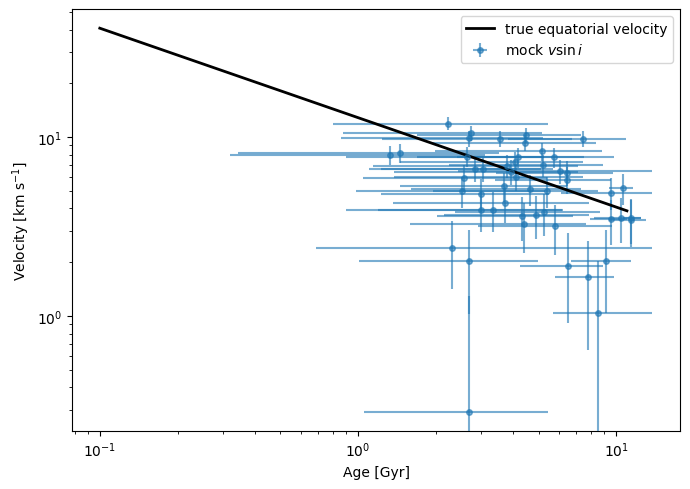

In [4]:
age_grid = np.geomspace(0.1, 11.0, 300)
fig, ax = plt.subplots(figsize=(7, 5))
age_q16, age_q50, age_q84 = np.quantile(age_samples, [0.16, 0.50, 0.84], axis=1)
age_xerr = np.vstack((age_q50 - age_q16, age_q84 - age_q50))

ax.errorbar(
    age_q50,
    vsini_obs,
    xerr=age_xerr,
    yerr=VSINI_ERR,
    fmt="o",
    ms=4,
    alpha=0.6,
    label=r"mock $v\sin i$",
)
ax.plot(age_grid, v_power(age_grid, A_TRUE, B_TRUE), color="black", lw=2, label="true equatorial velocity")
ax.set(xlabel="Age [Gyr]", ylabel=r"Velocity [km s$^{-1}$]",
    #    ylim=[None,None],xlim=[None,None],
       xscale="log",yscale="log"
       )
ax.legend()
fig.tight_layout()
fig.savefig(SIM_OUTPUT_DIR / "mock_data.png", dpi=200, bbox_inches="tight")

## True age vs observed age

Isochrone posteriorの16・50・84%点を、真の年齢に対して比較する。

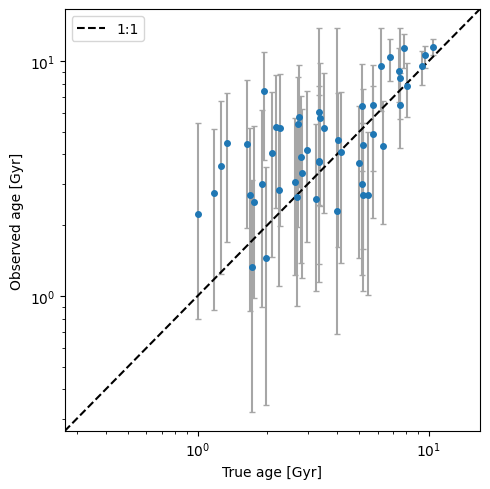

In [5]:
def identity_plot_limits(*arrays):
    values = np.concatenate([np.asarray(array, dtype=float).ravel() for array in arrays])
    positive = values[np.isfinite(values) & (values > 0)]
    if positive.size == 0:
        raise ValueError("No positive finite ages are available for log axes")
    log_limits = np.log10([positive.min(), positive.max()])
    log_span = max(log_limits[1] - log_limits[0], 0.1)
    return 10 ** np.array([
        log_limits[0] - 0.05 * log_span,
        log_limits[1] + 0.05 * log_span,
    ])


age_observation_limits = identity_plot_limits(age_true, age_q16, age_q84)
fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(
    age_true,
    age_q50,
    yerr=age_xerr,
    fmt="o",
    ms=4,
    color="C0",
    ecolor="0.65",
    capsize=2,
)
ax.plot(age_observation_limits, age_observation_limits, color="black", ls="--", label="1:1")
ax.set(
    xscale="log",
    yscale="log",
    xlim=age_observation_limits,
    ylim=age_observation_limits,
    xlabel="True age [Gyr]",
    ylabel="Observed age [Gyr]",
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SIM_OUTPUT_DIR / "age_true_vs_age_obs.png",
    dpi=200,
    bbox_inches="tight",
)

## Fit with `re_sim.model`

`isochrone_posterior` から得た年齢中央値と標準偏差を `re_sim.age`・`re_sim.age_err` として使い、各星の真の年齢、傾斜角、速度のpower law、母集団のlog-age分布（`predict_age_dist=True`）を同時に推定する。

In [6]:
model_args = (True,)
kernel = NUTS(re_sim.model, target_accept_prob=TARGET_ACCEPT_PROB)
mcmc = MCMC(
    kernel,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    chain_method="parallel",
    progress_bar=True,
)
mcmc.run(jax.random.PRNGKey(RNG_SEED + 1), *model_args)
idata = az.from_numpyro(mcmc)
idata.attrs.update({
    "simulation_label": SIM_LABEL,
    "rng_seed": RNG_SEED,
    "n_stars": N_STARS,
    "n_iso_samples": N_ISO_SAMPLES,
    "a_true": A_TRUE,
    "b_true": B_TRUE,
    "age_error_source": "isochrone_posterior",
    "vsini_err_km_s": VSINI_ERR,
    "logage_mu_true": LOGAGE_PRIOR_MU_TRUE,
    "logage_sigma_true": LOGAGE_PRIOR_SIGMA_TRUE,
    "num_warmup": NUM_WARMUP,
    "num_samples": NUM_SAMPLES,
    "num_chains": NUM_CHAINS,
    "target_accept_prob": 0.9,
    "inference_model": "RotEvol.model",
    "predict_age_dist": str(model_args[0]),
})
az.summary(
    idata,
    var_names=["a", "b", "logage_prior_mu", "logage_prior_sigma"],
    hdi_prob=0.68,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

,mean,sd,hdi_16%,hdi_84%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-0.711,0.161,-0.840,-0.537,0.006,0.004,714.0,1203.0,1.0
b,6.792,0.574,6.215,7.324,0.021,0.011,743.0,1458.0,1.0
logage_prior_mu,9.648,0.053,9.602,9.700,0.002,0.001,668.0,987.0,1.0
logage_prior_sigma,0.207,0.040,0.165,0.237,0.002,0.001,582.0,954.0,1.0


## True age vs predicted age

`re_sim.model` が推定した各星の年齢posteriorの16・50・84%点を、真の年齢に対して比較する。

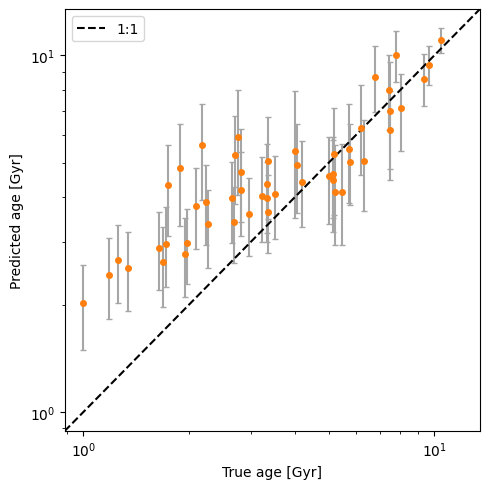

In [7]:
posterior_age = np.asarray(idata.posterior["age"], dtype=float)
if posterior_age.shape[-1] != N_STARS:
    raise ValueError(
        f"Expected the last posterior age dimension to be {N_STARS}, "
        f"got {posterior_age.shape}"
    )
age_predict_samples = posterior_age.reshape(-1, N_STARS).T
age_predict_q16, age_predict_q50, age_predict_q84 = np.quantile(
    age_predict_samples,
    [0.16, 0.50, 0.84],
    axis=1,
)
age_predict_yerr = np.vstack((
    age_predict_q50 - age_predict_q16,
    age_predict_q84 - age_predict_q50,
))

age_prediction_limits = identity_plot_limits(
    age_true,
    age_predict_q16,
    age_predict_q84,
)
fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(
    age_true,
    age_predict_q50,
    yerr=age_predict_yerr,
    fmt="o",
    ms=4,
    color="C1",
    ecolor="0.65",
    capsize=2,
)
ax.plot(age_prediction_limits, age_prediction_limits, color="black", ls="--", label="1:1")
ax.set(
    xscale="log",
    yscale="log",
    xlim=age_prediction_limits,
    ylim=age_prediction_limits,
    xlabel="True age [Gyr]",
    ylabel="Predicted age [Gyr]",
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SIM_OUTPUT_DIR / "age_true_vs_age_predict.png",
    dpi=200,
    bbox_inches="tight",
)

## Save outputs

`run_rot_evol.py` と同じ保存関数を使い、推定結果と標準診断図を `sim/<SIM_LABEL>/` に保存する。加えて、真の年齢、mock starのIsochrone posterior年齢、`re_sim.model` のposterior年齢を `age_comparison_samples.npz` に保存する。

In [8]:
inference_path = save_inference_data(
    re_sim,
    idata,
    SIM_LABEL,
    result_root=SIM_ROOT,
)
standard_figure_paths = save_figures(
    re_sim,
    idata,
    SIM_LABEL,
    predict_P_rot=False,
    result_root=SIM_ROOT,
)
logage_histogram_path = save_logage_histogram(
    re_sim,
    SIM_OUTPUT_DIR / "logage_hist.png",
    idata=idata,
)

if age_samples.shape[0] != N_STARS:
    raise ValueError(f"Expected age_obs samples for {N_STARS} stars, got {age_samples.shape}")
if age_predict_samples.shape[0] != N_STARS:
    raise ValueError(
        f"Expected age_predict samples for {N_STARS} stars, "
        f"got {age_predict_samples.shape}"
    )
age_comparison_path = SIM_OUTPUT_DIR / "age_comparison_samples.npz"
np.savez_compressed(
    age_comparison_path,
    frame_id=np.asarray(re_sim.frame_id),
    age_true=np.asarray(age_true, dtype=float),
    age_obs=np.asarray(age_samples, dtype=float),
    age_predict=np.asarray(age_predict_samples, dtype=float),
    age_unit=np.asarray("Gyr"),
)

saved_paths = {
    "inference": inference_path,
    **standard_figure_paths,
    "logage_hist": logage_histogram_path,
    "age_comparison_samples": age_comparison_path,
    "mock_data": SIM_OUTPUT_DIR / "mock_data.png",
    "age_true_vs_age_obs": SIM_OUTPUT_DIR / "age_true_vs_age_obs.png",
    "age_true_vs_age_predict": SIM_OUTPUT_DIR / "age_true_vs_age_predict.png",
}
print(f"Saved standard outputs under {SIM_OUTPUT_DIR}")
for name, saved_path in saved_paths.items():
    print(f"  {name}: {saved_path}")
print("Additional simulation figures are saved by the recovery cells below:")
for filename in ("recovery_trace.png", "recovery_corner.png", "recovery_relation.png"):
    print(f"  {SIM_OUTPUT_DIR / filename}")

Saved standard outputs under sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3
  inference: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/mcmc.nc
  corner: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/corner.png
  trace: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/trace.png
  rotation: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/rotation.png
  vsini_obs_vs_post: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/vsini_obs_vs_post.png
  age_obs_vs_post: sim/Nstar50_atruem0p5_btrue6_tefferr100_gmagerr0p02_feherr0p1_plxerr0p01_vsinierr1_logage_mu9p6_logage_sigma0p3/age_obs_vs_post.png
  logage_hist: sim/

## Recovery check

事後中央値と68% HDIを真値と比較する。有限個の模擬データなので中央値が真値と完全一致する必要はないが、正しく較正された推定では真値が信用区間内に入ることが期待される。

In [9]:
posterior = idata.posterior.stack(sample=("chain", "draw"))

def recovery_row(name, truth):
    values = np.asarray(posterior[name])
    low, median, high = np.quantile(values, [0.03, 0.5, 0.97])
    return {
        "parameter": name,
        "truth": truth,
        "median": median,
        "94% interval": (low, high),
        "truth in interval": bool(low <= truth <= high),
    }

recovery = [recovery_row("a", A_TRUE), recovery_row("b", B_TRUE)]
for row in recovery:
    print(row)

all_recovered = all(row["truth in interval"] for row in recovery)
print("Both parameters recovered within their 94% intervals:", all_recovered)

{'parameter': 'a', 'truth': -0.5, 'median': np.float64(-0.6949000325384949), '94% interval': (np.float64(-1.051121318976703), np.float64(-0.4474294037817029)), 'truth in interval': True}
{'parameter': 'b', 'truth': 6, 'median': np.float64(6.781124165484924), '94% interval': (np.float64(5.763650215127956), np.float64(7.914177692623195)), 'truth in interval': True}
Both parameters recovered within their 94% intervals: True


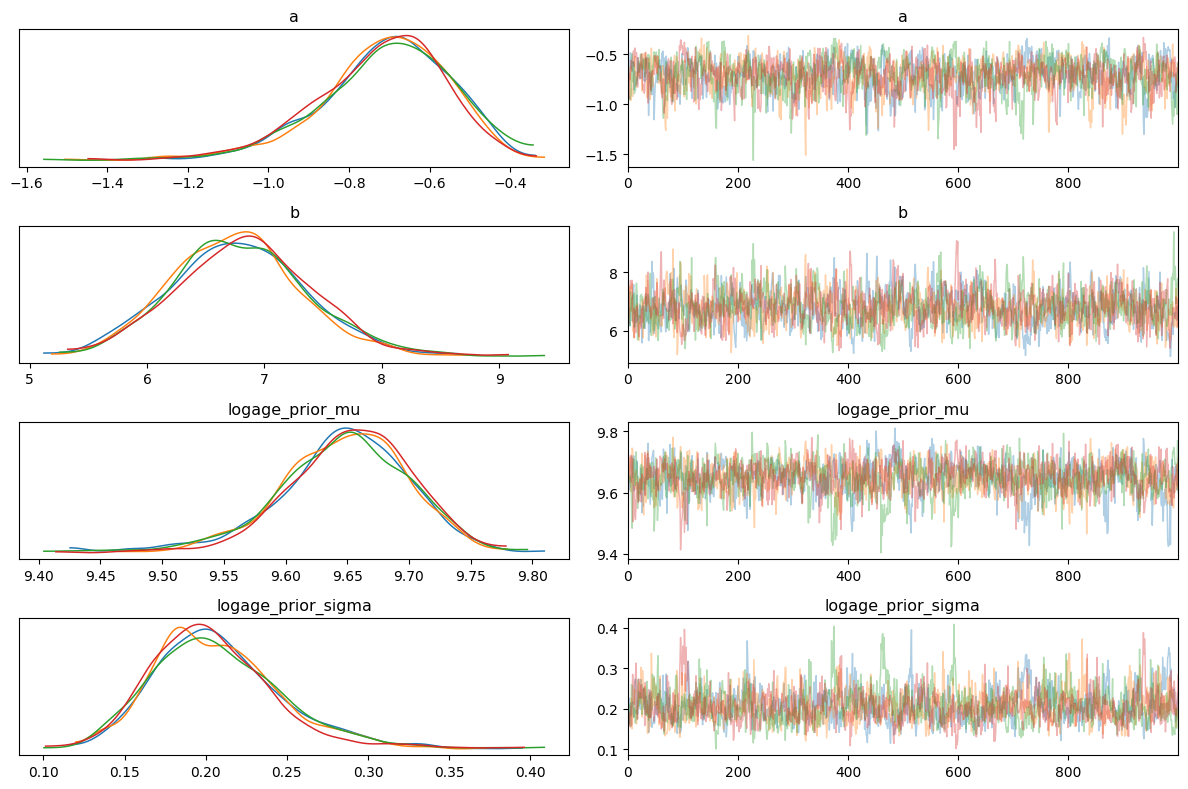

In [10]:
trace_axes = az.plot_trace(
    idata,
    var_names=["a", "b", "logage_prior_mu", "logage_prior_sigma"],
    compact=False,
)
trace_figure = np.asarray(trace_axes).flat[0].figure
trace_figure.tight_layout()
trace_figure.savefig(
    SIM_OUTPUT_DIR / "recovery_trace.png",
    dpi=200,
    bbox_inches="tight",
)

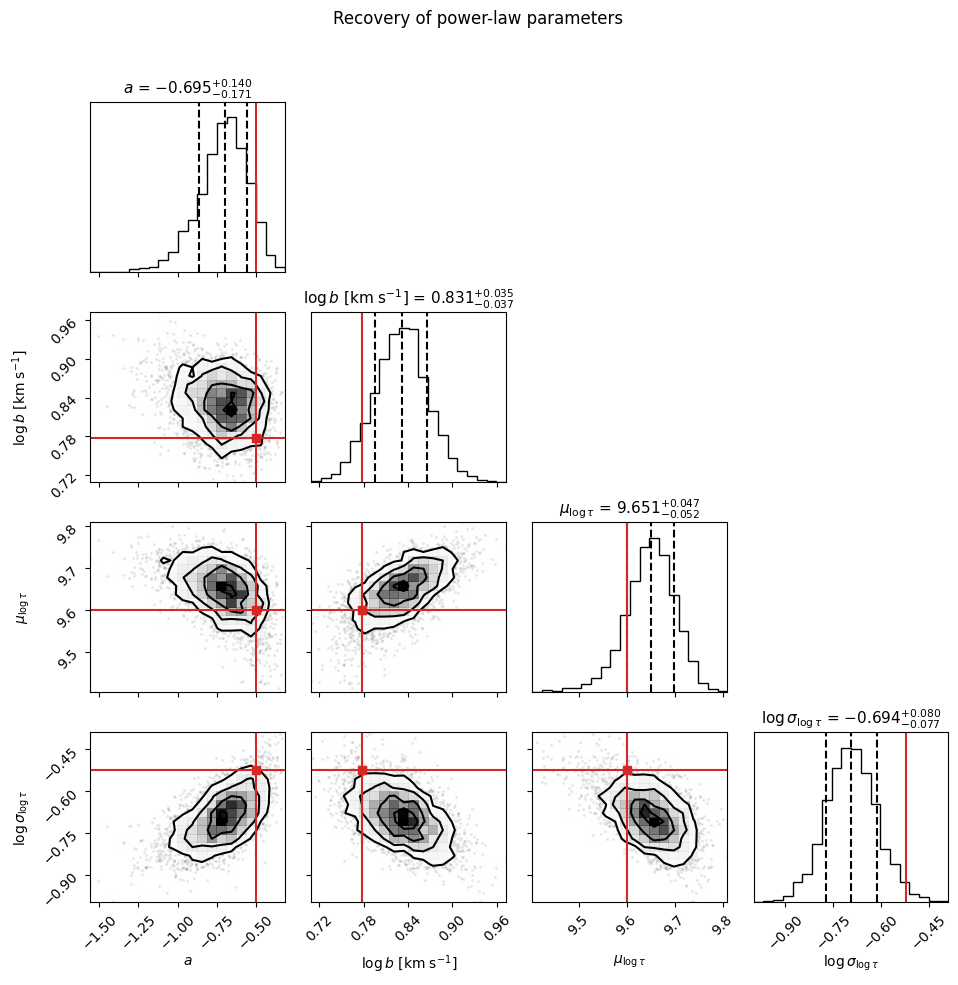

In [14]:
ab_samples = np.column_stack([
    np.asarray(posterior["a"]),
    np.asarray(posterior["logb"]),
    np.asarray(posterior["logage_prior_mu"]),
    np.asarray(posterior["loglogage_prior_sigma"]),
])
truths = [
    A_TRUE,
    np.log10(B_TRUE),
    LOGAGE_PRIOR_MU_TRUE,
    np.log10(LOGAGE_PRIOR_SIGMA_TRUE),
]

figure = corner.corner(
    ab_samples,
    labels=[
        r"$a$",
        r"$\log b$ [km s$^{-1}$]",
        r"$\mu_{\log \tau}$",
        r"$\log\sigma_{\log \tau}$",
    ],
    truths=truths,
    truth_color="C3",
    truth_kwargs={"linewidth": 2.5, "alpha": 1.0},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 11},
)
figure.suptitle("Recovery of power-law parameters", y=1.02)
plt.tight_layout()
figure.savefig(SIM_OUTPUT_DIR / "recovery_corner.png", dpi=200, bbox_inches="tight")


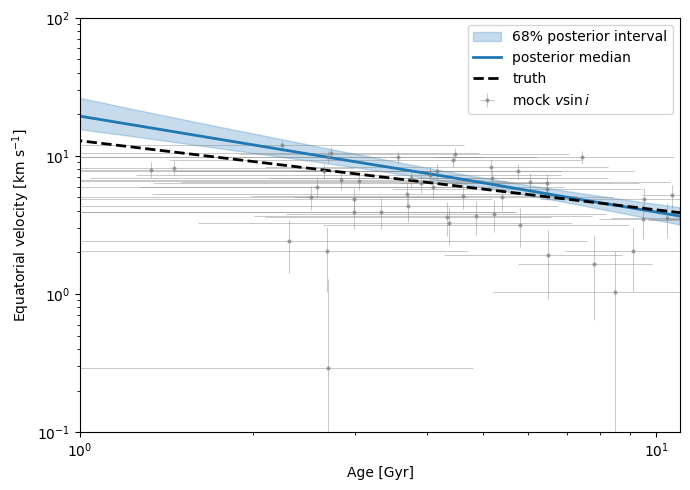

In [12]:
from matplotlib.pyplot import xlim


a_draw = np.asarray(posterior["a"])[:, None]
b_draw = np.asarray(posterior["b"])[:, None]
v_draw = np.asarray(v_power(age_grid[None, :], a_draw, b_draw))
low, median, high = np.quantile(v_draw, [0.16, 0.5, 0.84], axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    age_obs, vsini_obs, xerr=age_err, yerr=VSINI_ERR, fmt=".", ms=4, alpha=0.6, label=r"mock $v\sin i$",
    elinewidth=0.5,color="gray"
)

ax.fill_between(age_grid, low, high, alpha=0.25, color="C0", label="68% posterior interval")
ax.plot(age_grid, median, color="C0", lw=2, label="posterior median")
ax.plot(age_grid, v_power(age_grid, A_TRUE, B_TRUE), color="black", ls="--", lw=2, label="truth")
ax.set(
    xscale="log", yscale="log", xlabel="Age [Gyr]", ylabel=r"Equatorial velocity [km s$^{-1}$]",
    xlim=(1, 11), ylim=(0.1, 100)
       )
ax.legend()
fig.tight_layout()
fig.savefig(SIM_OUTPUT_DIR / "recovery_relation.png", dpi=200, bbox_inches="tight")

mock星を使ってmodelの検証を行いました。
lognormalなage分布からage_trueをサンプリングしてmass=1,feh=0のmock星を50個作り、
それらの星のgmagとteffを観測誤差はgmagとteffの0.02 mag,100K,parallaxの誤差 0.01masで与えて
それを観測値とその誤差をつくりました。
それを用いてそれぞれの星でisochrone fitして事後分布を得て、p(t|D_iso)としました。
vsiniは真値v(age_true,a,b)*siniから、典型的な誤差1km/sの正規分布の誤差を与え,p(vsini|D_spec)としました。

次に真の年齢と真の自転速度がpowerlawに従うという階層モデルと、
isochroneで得たそれぞれの星の年齢の情報p(t|D_iso)とvsiniの測定の情報p(vsini|D_spec)
これらを用いて
べき乗の２つの定数と真の年齢分布の推定を行いました。
ここではimportance samplingではなく,ageの観測誤差を正規分布としました。

その結果です。
